# BTC 15-Min Directional Model — Research / Trainer
**Matches the live bot exactly** (`main.py` + `model.py` + `strategy.py` + `stream.py`).

This notebook trains the logistic regression that the live bot runs. It uses the **identical features** computed in `stream.py.get_features()` and the **identical decision rule** in `strategy.py`/`model.py`, then prints the trained `weights`, `feature_mean`, and `feature_std` to paste into `model.py`.

**Live feature set (window = 100 closed 15-min candles):**
- `log_returns` = ln(close[-1] / close[0]) over the 100-window
- `volatility` = std(window)
- `rsi` = RSI over the window
- `sma_ratio` = mean(last 20) / mean(all 100)
- (`sma` is computed but not a model input)

**Decision rule:** prob >= 0.55 -> BET_UP (buy YES); prob <= 0.45 -> BET_DOWN (buy NO); else HOLD.

## 1 · Config

In [7]:
import math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Match the live system exactly
WINDOW        = 100      # stream.py MarketStream(max_len=100)
SHORT_WINDOW  = 20       # stream.py sma_ratio short window
CANDLE_SECONDS= 900      # 15-min candles
SYMBOL        = "BTC-USD"
GRANULARITY   = "FIFTEEN_MINUTE"

UP_THRESHOLD  = 0.53     # strategy.py / model.py
DOWN_THRESHOLD= 0.47

# Backtest costs
KALSHI_FEE_MULT = 0.07   # taker fee approx; round(0.07*p*(1-p),2) per contract
FIXED_PRICE     = 0.50   # main.py FIXED_PRICE
INIT_CAPITAL    = 100.0

TARGET_CANDLES  = 6000   # ~62 days of 15-min candles
TRAIN_SPLIT     = 0.70

FEATURE_NAMES = ["log_returns","volatility","rsi","sma_ratio"]
print("config loaded — matches live bot (window=100, thresholds 0.55/0.45)")

config loaded — matches live bot (window=100, thresholds 0.55/0.45)


## 2 · Pull BTC candles (same Coinbase API as stream.py)

In [8]:
def download_btc(target=TARGET_CANDLES):
    url=f"https://api.coinbase.com/api/v3/brokerage/market/products/{SYMBOL}/candles"
    rows=[]; end=int(time.time()); pages=math.ceil(target/300)
    for _ in range(pages):
        start=end-300*CANDLE_SECONDS
        r=requests.get(url,params={"start":str(start),"end":str(end),
                       "granularity":GRANULARITY,"limit":300},timeout=15)
        r.raise_for_status(); rows+=r.json().get("candles",[]); end=start; time.sleep(0.25)
    d=pd.DataFrame(rows)[["start","close"]]
    d["start"]=pd.to_datetime(d["start"].astype(int),unit="s",utc=True)
    d["close"]=d["close"].astype(float)
    d=d.rename(columns={"start":"timestamp"}).sort_values("timestamp").drop_duplicates("timestamp").reset_index(drop=True)
    return d[d["close"]>0].reset_index(drop=True)

df=download_btc()
print(f"pulled {len(df)} candles  {df.timestamp.min()} -> {df.timestamp.max()}")

pulled 5975 candles  2026-04-03 13:30:00+00:00 -> 2026-06-05 01:15:00+00:00


## 3 · Build features — IDENTICAL to stream.py.get_features()
*Each row uses the 100-candle window ENDING at that row (the candles closed BEFORE the window we predict), then the target is whether the NEXT candle closes up. This matches the live bot: it predicts the next 15-min direction from the last 100 closed candles.*

In [9]:
def features_for_window(arr):
    # arr = np.array of the last WINDOW closes (oldest..newest). Mirrors stream.py exactly.
    sma = np.mean(arr)
    log_returns = np.log(arr[-1]/arr[0]) if arr[0]>0 and arr[-1]>0 else 0.0
    volatility = np.std(arr)
    diffs = np.diff(arr)
    gains = diffs[diffs>0].sum(); losses = -diffs[diffs<0].sum()
    if losses==0: rsi=100.0
    elif gains==0: rsi=0.0
    else: rsi=100.0-(100.0/(1.0+gains/losses))
    short_sma = np.mean(arr[-SHORT_WINDOW:])
    sma_ratio = short_sma/sma if sma>0 else 1.0
    return {"sma":sma,"log_returns":log_returns,"volatility":volatility,"rsi":rsi,"sma_ratio":sma_ratio}

closes=df["close"].values
rows=[]
# i indexes the LAST candle in the window; we predict candle i+1
for i in range(WINDOW-1, len(closes)-1):
    arr=closes[i-WINDOW+1:i+1]               # 100 closed candles up to and including i
    f=features_for_window(arr)
    nxt_up = 1 if closes[i+1] > closes[i] else 0   # next candle direction
    f["target"]=nxt_up
    f["ts"]=df["timestamp"].values[i]
    rows.append(f)
feat=pd.DataFrame(rows)
print(f"built {len(feat)} feature rows")
print(feat[FEATURE_NAMES].describe().round(4).to_string())

built 5875 feature rows
       log_returns  volatility        rsi  sma_ratio
count    5875.0000   5875.0000  5875.0000  5875.0000
mean       -0.0009    499.2689    49.7937     0.9997
std         0.0199    297.7015     6.8299     0.0091
min        -0.0778    102.6304    31.2187     0.9652
25%        -0.0130    285.7992    44.8320     0.9946
50%        -0.0001    416.1864    49.9726     0.9999
75%         0.0098    622.9502    54.5215     1.0041
max         0.0663   1577.2458    69.0794     1.0340


## 4 · Train logistic regression (the weights for model.py)
*Standardize features (the scaling model.py expects), train, and PRINT the constants to paste into model.py.*

In [10]:
split=int(len(feat)*TRAIN_SPLIT)
train,test=feat.iloc[:split].copy(), feat.iloc[split:].copy()

X_mean=train[FEATURE_NAMES].mean(); X_std=train[FEATURE_NAMES].std().replace(0,1)
Xtr=((train[FEATURE_NAMES]-X_mean)/X_std).values
Xte=((test[FEATURE_NAMES]-X_mean)/X_std).values
ytr=train["target"].values.astype(float); yte=test["target"].values.astype(float)

def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-100,100)))
def train_logreg(X,y,epochs=8000,lr=0.05):
    w=np.zeros(X.shape[1]); b=0.0; losses=[]
    for _ in range(epochs):
        p=sigmoid(X@w+b); err=p-y
        w-=lr*(X.T@err/len(y)); b-=lr*err.mean()
        losses.append(-np.mean(y*np.log(p+1e-9)+(1-y)*np.log(1-p+1e-9)))
    return w,b,losses
w,b,losses=train_logreg(Xtr,ytr)
print(f"final loss: {losses[-1]:.5f}  (0.6931 = coin flip)")
try:
    auc=roc_auc_score(yte, sigmoid(Xte@w+b))
    print(f"OUT-OF-SAMPLE ROC AUC: {auc:.4f}  (0.5 = no edge)")
except Exception as e: print("AUC err:",e)

print("\n# ---- paste into model.py ----")
print("self.weights = {")
for n,wi in zip(FEATURE_NAMES,w): print(f'    "{n}": {wi:.6f},')
print("}")
print(f"self.bias = {b:.6f}")
print("self.feature_mean = {"+", ".join(f'"{n}": {X_mean[n]:.6f}' for n in FEATURE_NAMES)+"}")
print("self.feature_std  = {"+", ".join(f'"{n}": {X_std[n]:.6f}' for n in FEATURE_NAMES)+"}")

final loss: 0.69186  (0.6931 = coin flip)
OUT-OF-SAMPLE ROC AUC: 0.5094  (0.5 = no edge)

# ---- paste into model.py ----
self.weights = {
    "log_returns": -0.082708,
    "volatility": 0.018233,
    "rsi": -0.081584,
    "sma_ratio": 0.089728,
}
self.bias = 0.033172
self.feature_mean = {"log_returns": 0.003732, "volatility": 494.614227, "rsi": 51.100683, "sma_ratio": 1.001522}
self.feature_std  = {"log_returns": 0.017765, "volatility": 278.960711, "rsi": 6.535149, "sma_ratio": 0.008431}


## 5 · Backtest the live decision rule (with costs)
*Apply prob>=0.55 -> YES, prob<=0.45 -> NO, else HOLD, at fixed 0.50, settle on next-candle direction. Subtract Kalshi fee. This is what the live bot does.*

trades: 701 | win rate: 48.1% | net P&L: $-25.77 | final: $74.23


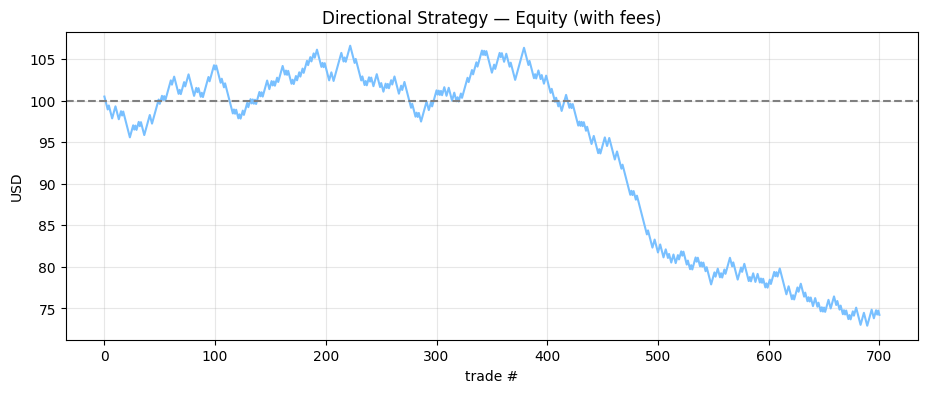

In [11]:
test=test.copy(); test["prob_up"]=sigmoid(Xte@w+b)
trades=[]
for _,r in test.iterrows():
    p=r["prob_up"]
    if p>=UP_THRESHOLD: side="YES"
    elif p<=DOWN_THRESHOLD: side="NO"
    else: continue
    won = (side=="YES" and r["target"]==1) or (side=="NO" and r["target"]==0)
    entry=FIXED_PRICE
    gross=(1.0-entry) if won else -entry
    fee=round(KALSHI_FEE_MULT*entry*(1.0-entry),4)
    trades.append({"won":int(won),"net":gross-fee})
td=pd.DataFrame(trades)
if td.empty:
    print("No trades (model never crossed 0.55/0.45). Confidence too flat.")
else:
    wr=td["won"].mean(); tot=td["net"].sum()
    print(f"trades: {len(td)} | win rate: {wr:.1%} | net P&L: ${tot:+.2f} | final: ${INIT_CAPITAL+tot:.2f}")
    eq=INIT_CAPITAL+td["net"].cumsum()
    plt.figure(figsize=(11,4)); plt.plot(eq.values,color="#79c0ff")
    plt.axhline(INIT_CAPITAL,ls="--",c="gray"); plt.title("Directional Strategy — Equity (with fees)")
    plt.xlabel("trade #"); plt.ylabel("USD"); plt.grid(alpha=.3); plt.show()
    if wr>0.75: print("WARNING: >75% win rate = likely leak.")